# 33회 ADP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

# 기계학습 (60점)

## 데이터 설명
- 데이터 출처 : https://archive.ics.uci.edu/ml/datasets/HCV+data 후처리
- 데이터 링크 : ./p1.csv
- 데이터 설명 : 혈액수치 데이터, 간염 정도에 따른

Category (종속변수) 
- 0: 정상
- 1,2,3 (간염 정도, 심각성 : 3>2>1, 3은 간경화)


In [2]:
d1 = pd.read_csv("./p1.csv")
d1.head()

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=B,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=B,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=B,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0=B,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0=B,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [3]:
d1.isna().sum()

Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64

In [4]:
d1.isna().mean()

Category    0.000000
Age         0.000000
Sex         0.000000
ALB         0.001645
ALP         0.029605
ALT         0.001645
AST         0.000000
BIL         0.000000
CHE         0.000000
CHOL        0.016447
CREA        0.000000
GGT         0.000000
PROT        0.001645
dtype: float64

## 1-1  결측치 처리 방안 2개 제시하고, 처리 전후 비교 및 더 나은 방안 선택하여 전처리 완료

 - 결측치 제거: 3개의 컬럼에서 미미한 수준의 결측치 존재, 삭제를 통해 데이터 왜곡을 피할 수 있음
 - 대표값 대치(중앙값): 비교적 데이터 왜곡의 정도가 낮은 대푯값인 중앙값 대치를 통해 데이터 손실을 피할 수 있음

결측치 제거 전 사이즈: 608
결측치 제거 후 사이즈: 582


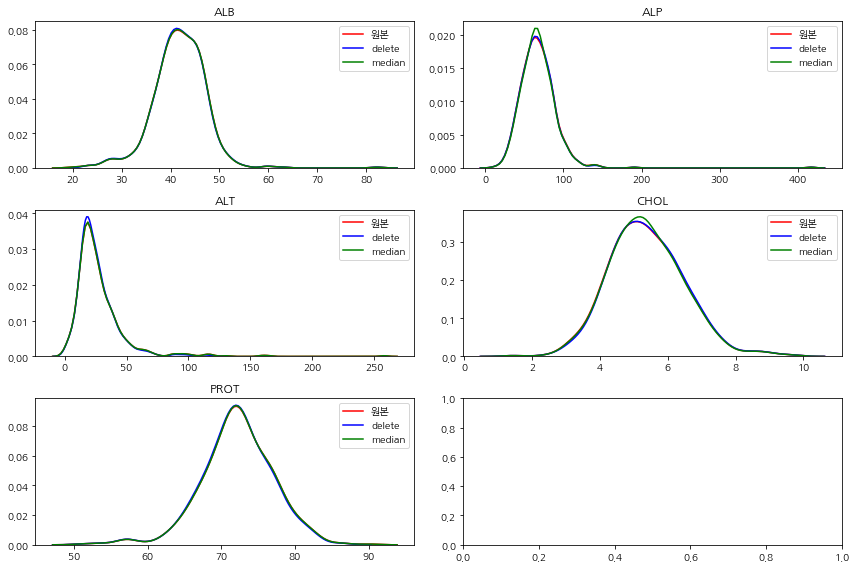

<<원본>>


,count,mean,std,min,25%,50%,75%,max
ALB,607.0,41.818781,5.406717,20.00,39.00,42.0,45.250,82.20
ALP,590.0,67.821017,25.274423,11.30,52.50,66.0,79.525,416.60
ALT,607.0,27.601318,21.227539,0.90,16.40,23.0,32.750,258.00
CHOL,598.0,5.378829,1.119394,1.43,4.62,5.3,6.075,9.67
PROT,607.0,72.253213,4.932252,51.00,69.45,72.2,75.400,90.00


<<delete>>


,count,mean,std,min,25%,50%,75%,max
ALB,582.0,41.831443,5.369272,23.00,39.000,41.95,45.1750,82.20
ALP,582.0,67.651890,25.148941,11.30,52.500,66.00,79.3000,416.60
ALT,582.0,25.666838,14.920906,0.90,16.325,22.50,31.7500,118.10
CHOL,582.0,5.402646,1.114920,1.43,4.630,5.31,6.0875,9.67
PROT,582.0,72.106357,4.857867,51.00,69.300,72.10,75.2000,86.50


<<median>>


,count,mean,std,min,25%,50%,75%,max
ALB,608.0,41.819079,5.402266,20.00,39.0000,42.0,45.225,82.20
ALP,608.0,67.767105,24.898775,11.30,52.9000,66.0,79.025,416.60
ALT,608.0,27.593750,21.210867,0.90,16.4000,23.0,32.675,258.00
CHOL,608.0,5.377533,1.110180,1.43,4.6275,5.3,6.060,9.67
PROT,608.0,72.253125,4.928188,51.00,69.4750,72.2,75.400,90.00


In [5]:
d_cols = d1.loc[:, d1.isna().sum() > 0].columns

# 결측치 제거 
print(f"결측치 제거 전 사이즈: {len(d1)}")
d1_d = d1.dropna()
print(f"결측치 제거 후 사이즈: {len(d1_d)}")

#중앙값 보간
d1_d2 = d1.fillna(d1.median())

dt_list = [('원본', d1, 'r'), ('delete', d1_d, 'b'), ('median', d1_d2, 'g')]

fig, ax = plt.subplots(3, 2, figsize=(12, 8))

for col, ax in zip(d_cols, ax.flatten()):
    for d_name, dt, c in dt_list:
        sns.kdeplot(data=dt[col], color=c, ax=ax, label=d_name)
        ax.set_title(col)
plt.tight_layout()
plt.show()

for d_name, dt, c in dt_list:
    print(f"<<{d_name}>>")
    display(dt[d_cols].describe().T)

중앙값 결측치 보간, 삭제 후 원본과의 통계량 비교 및 시각화를 통해, 결측치 삭제가 원본데이터와의 분포가 유사한 것을 알 수 있다.  
따라서 삭제한다. 

In [6]:
d1 = d1.dropna()

## 1-2 이상치를 확인하고 처리 여부 판단 후 작업

In [7]:
ds = d1.describe().T
q1 = ds['25%']
q3 = ds['75%']
iqr = q3 - q1
top = q3 + (1.5*iqr)
down = q1 - (1.5*iqr)

print(f"IQR 기준 상하단 이상치 수")
for idx in top.index:
    cnt = len(d1[(d1[idx] > top[idx])| (d1[idx] < down[idx])])
    print(f"- {idx} ({down[idx]:.3f} ~ {top[idx]:.3f}): {cnt}")

IQR 기준 상하단 이상치 수
- Age (16.500 ~ 76.500): 1
- ALB (29.737 ~ 54.438): 21
- ALP (12.300 ~ 119.500): 10
- ALT (-6.813 ~ 54.888): 24
- AST (6.162 ~ 46.863): 53
- BIL (-3.250 ~ 19.550): 48
- CHE (3.027 ~ 13.488): 22
- CHOL (2.444 ~ 8.274): 12
- CREA (36.500 ~ 120.500): 8
- GGT (-15.675 ~ 67.325): 71
- PROT (60.450 ~ 84.050): 13


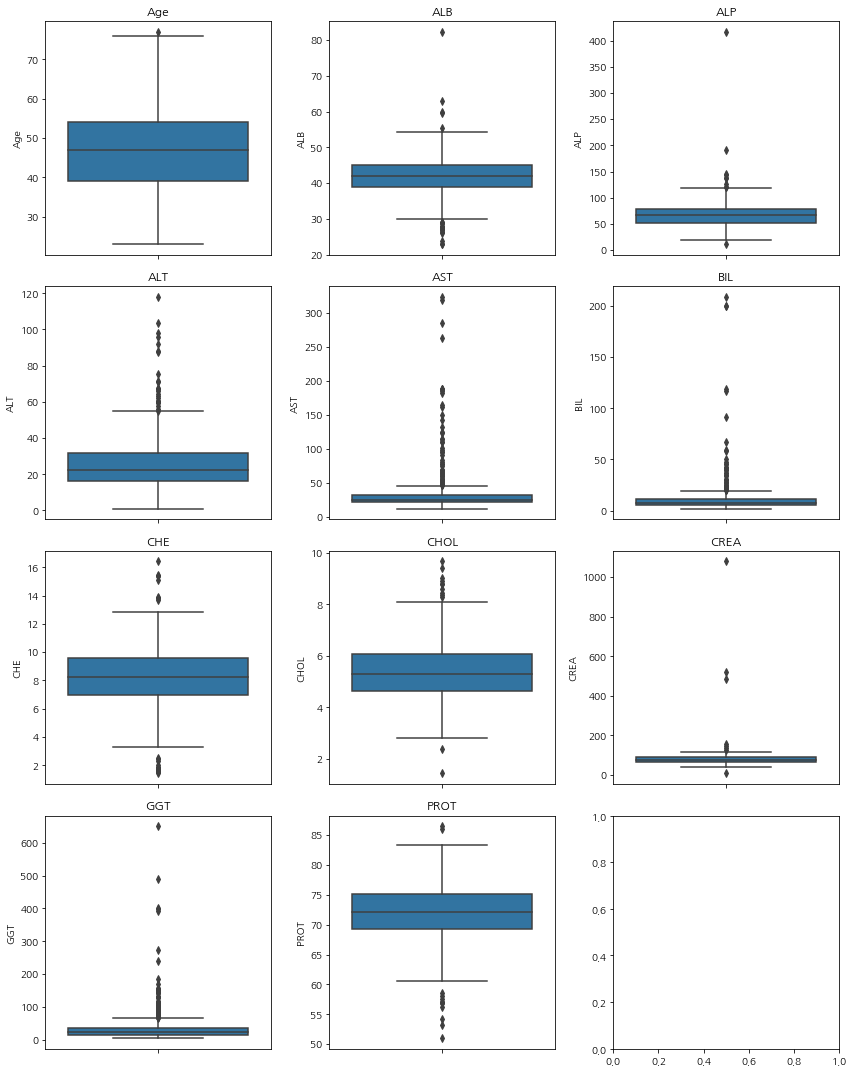

In [8]:
fig, ax = plt.subplots(4, 3, figsize=(12, 15))

for ax, col in zip(ax.flatten(), top.index):
    sns.boxplot(y=d1[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

IQR  기준으로 다음과 같이 이상치가 판별되었다. 

IQR 기준 상하단 이상치 수
- Age (16.500 ~ 76.500): 1
- ALB (29.737 ~ 54.438): 21
- ALP (12.300 ~ 119.500): 10
- ALT (-6.813 ~ 54.888): 24
- AST (6.162 ~ 46.863): 53
- BIL (-3.250 ~ 19.550): 48
- CHE (3.027 ~ 13.488): 22
- CHOL (2.444 ~ 8.274): 12
- CREA (36.500 ~ 120.500): 8
- GGT (-15.675 ~ 67.325): 71
- PROT (60.450 ~ 84.050): 13

하지만, 데이터 정보를 정확히 알지 못하는 상태에서 삭제를 하는 것은 적절치 않으므로 삭제하지 않는다.   
문제에 따라서는 이상치로 보이는 데이터도 의미있을 수 있기 때문이다.  
그리고 나이에서 식별된 이상치 후보군 1개도 실제로 70세-80세 사이는 실제적으로 가능한 데이터이므로 삭제하지 않는다.

## 1-3 위 두 작업 적용 후 EDA 진행) 및 종속변수를 기준으로 각 독립변수의 차이가 있는지 확인하라 (시각화포함)

연속형 변수 통계량 및 시각화


,count,mean,std,min,25%,50%,75%,max
Age,582.0,47.295533,9.863890,23.00,39.000,47.000,54.0000,77.00
ALB,582.0,41.831443,5.369272,23.00,39.000,41.950,45.1750,82.20
ALP,582.0,67.651890,25.148941,11.30,52.500,66.000,79.3000,416.60
ALT,582.0,25.666838,14.920906,0.90,16.325,22.500,31.7500,118.10
AST,582.0,33.325086,32.357234,12.00,21.425,25.600,31.6000,324.00
BIL,582.0,11.094330,17.494290,1.80,5.300,7.150,11.0000,209.00
CHE,582.0,8.212337,2.151660,1.42,6.950,8.265,9.5650,16.41
CHOL,582.0,5.402646,1.114920,1.43,4.630,5.310,6.0875,9.67
CREA,582.0,81.909107,50.669976,8.00,68.000,77.000,89.0000,1079.10
GGT,582.0,36.835567,51.409352,4.50,15.450,22.650,36.2000,650.90


Age      0.272293
ALB      0.419007
ALP      4.993523
ALT      1.955810
AST      5.475755
BIL      8.052368
CHE     -0.111852
CHOL     0.402209
CREA    15.145890
GGT      6.499546
PROT    -0.484351
dtype: float64


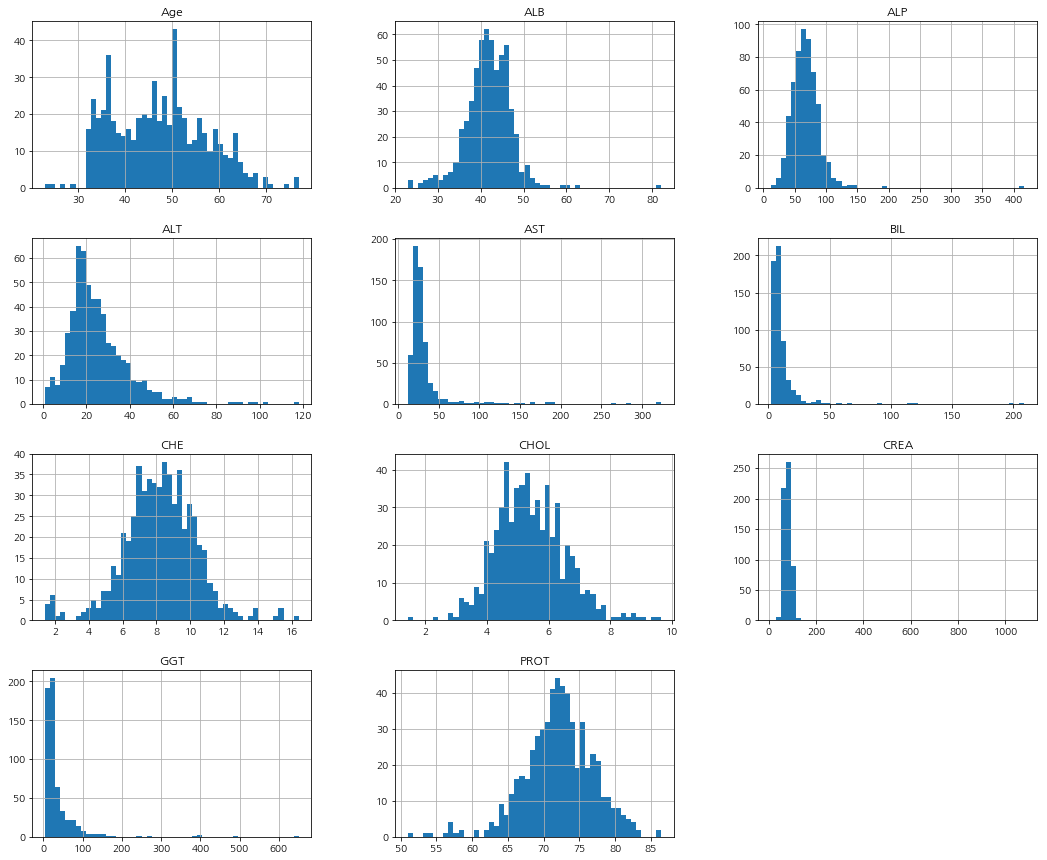

명목형 변수 통계량 및 시각화


,count,unique,top,freq
Category,582,4,0=B,526
Sex,582,2,m,357


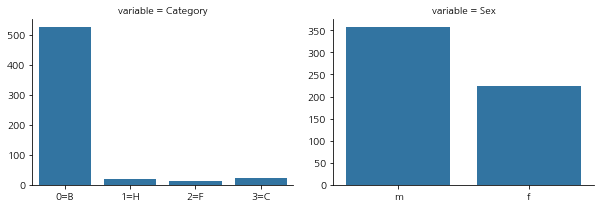

In [9]:
n_cols = d1.select_dtypes('number').columns
c_cols = d1.select_dtypes('O').columns

print(f"연속형 변수 통계량 및 시각화")
display(d1[n_cols].describe().T)
print(d1[n_cols].skew())
d1[n_cols].hist(figsize=(18, 15), bins=50, layout=(4, 3))
plt.show()

print(f"명목형 변수 통계량 및 시각화")
display(d1[c_cols].describe().T)
mt = d1[c_cols].melt()
g = sns.FacetGrid(mt, col='variable', col_wrap=4, height=3, aspect=1.4, sharex=False, sharey=False)
g.map_dataframe(sns.countplot, x='value')
plt.tight_layout()
plt.show()

BIL, CREA, GGT는 강한 양의 왜도(우측 긴꼬리 분포)를 띄며(log화를 통해 분포모양 교정 고려)  
CHE, CHOL, PROT는 정규분포에 가까움

카테고리와는 0=B가 압도적으로 많아 다른 레이블과의 불균형 분포를 보이며,   
남성이 여성보다 많음(3:5:2.3정도로 심한 불균형 아님)

In [10]:
#종속변수 기준으로 독립변수 차이가 있는지 검정
# 수치-종속(카테고리형, 그룹 3개) : 정규성 검정 후 만족하면 one-way anova, 만족 안하면 크루스칼 왈리스 검정
# 명목-명목: 카이제곱 독립성 검정
from  scipy.stats import shapiro, kruskal

#수치형
# 정규성 확인
for col in n_cols:
    gr = [(name, g[col]) for name, g in d1.groupby(['Category'])]
    print('-'*20)
    for name, g in gr:
        stat, p = shapiro(g)
        print(f"{col}-{name}: 정규성 만족여부", "만족" if p>=0.05 else "불만족")

--------------------
Age-0=B: 정규성 만족여부 불만족
Age-1=H: 정규성 만족여부 만족
Age-2=F: 정규성 만족여부 만족
Age-3=C: 정규성 만족여부 만족
--------------------
ALB-0=B: 정규성 만족여부 불만족
ALB-1=H: 정규성 만족여부 만족
ALB-2=F: 정규성 만족여부 만족
ALB-3=C: 정규성 만족여부 만족
--------------------
ALP-0=B: 정규성 만족여부 불만족
ALP-1=H: 정규성 만족여부 불만족
ALP-2=F: 정규성 만족여부 만족
ALP-3=C: 정규성 만족여부 불만족
--------------------
ALT-0=B: 정규성 만족여부 불만족
ALT-1=H: 정규성 만족여부 불만족
ALT-2=F: 정규성 만족여부 불만족
ALT-3=C: 정규성 만족여부 불만족
--------------------
AST-0=B: 정규성 만족여부 불만족
AST-1=H: 정규성 만족여부 불만족
AST-2=F: 정규성 만족여부 만족
AST-3=C: 정규성 만족여부 불만족
--------------------
BIL-0=B: 정규성 만족여부 불만족
BIL-1=H: 정규성 만족여부 불만족
BIL-2=F: 정규성 만족여부 만족
BIL-3=C: 정규성 만족여부 불만족
--------------------
CHE-0=B: 정규성 만족여부 불만족
CHE-1=H: 정규성 만족여부 만족
CHE-2=F: 정규성 만족여부 만족
CHE-3=C: 정규성 만족여부 불만족
--------------------
CHOL-0=B: 정규성 만족여부 불만족
CHOL-1=H: 정규성 만족여부 불만족
CHOL-2=F: 정규성 만족여부 만족
CHOL-3=C: 정규성 만족여부 만족
--------------------
CREA-0=B: 정규성 만족여부 불만족
CREA-1=H: 정규성 만족여부 불만족
CREA-2=F: 정규성 만족여부 만족
CREA-3=C: 정규성 만족여부 불만족
--------------------
GGT-

각 feature의 모든 그룹에서 정규성을 만족해야 모수검정을 수행할 수 있는데, 모든 피쳐에서 만족하지 않으므로 크루스칼 왈리스 검정

In [11]:
rr = []
for col in n_cols:
    gr = [g[col] for name, g in d1.groupby(['Category'])]
    stat, p = kruskal(*gr)
    if p < 0.05:
        rr.append(col)
    print(f"종속변수와 독립변수{col} 독립성 여부:", "독립" if p>=0.05 else "독립아님")

종속변수와 독립변수Age 독립성 여부: 독립아님
종속변수와 독립변수ALB 독립성 여부: 독립아님
종속변수와 독립변수ALP 독립성 여부: 독립아님
종속변수와 독립변수ALT 독립성 여부: 독립아님
종속변수와 독립변수AST 독립성 여부: 독립아님
종속변수와 독립변수BIL 독립성 여부: 독립아님
종속변수와 독립변수CHE 독립성 여부: 독립아님
종속변수와 독립변수CHOL 독립성 여부: 독립아님
종속변수와 독립변수CREA 독립성 여부: 독립아님
종속변수와 독립변수GGT 독립성 여부: 독립아님
종속변수와 독립변수PROT 독립성 여부: 독립아님


In [12]:
rr

['Age',
 'ALB',
 'ALP',
 'ALT',
 'AST',
 'BIL',
 'CHE',
 'CHOL',
 'CREA',
 'GGT',
 'PROT']

종속변수와 연관성이 있는 변수는 'Age' 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT',  'PROT'로   
크루스칼 왈리스 검정 결과 확인되었다.  
해당 변수는 종속변수를 분류하는 문제에서 연관특징을 사용하여 분류가 잘 되게하는 특징이 있다고 할 수 있다.

In [13]:
from scipy.stats import chi2_contingency

for col in c_cols[1:]:
    cr = pd.crosstab(d1['Category'], d1[col])
    stat, p, ddof, expected = chi2_contingency(cr)
    print(f"{col} 변수 독립성 검정결과({p:.3f}):", "독립" if p >=0.05 else "독립아님")

Sex 변수 독립성 검정결과(0.305): 독립


성별변수는 종속변수와 독립으로 연관관계가 없다.  
따라서 종속변수를 예측하기 위한 연관특징이 없다고 할 수 있다. 

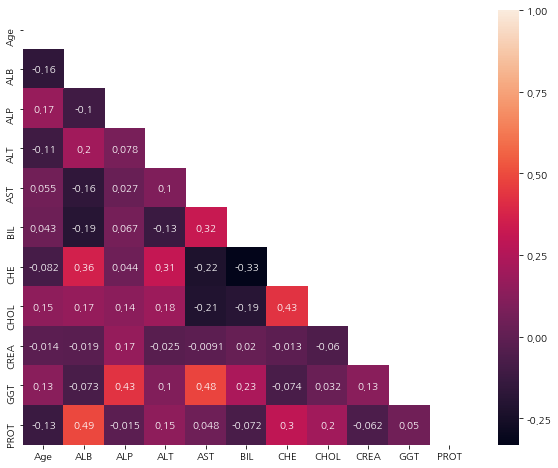

In [14]:
plt.figure(figsize=(10, 8))
corr = d1.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

피어슨 상관관계 분석결과, 1:1 변수 간 큰 상관관계는 식별되지 않는다. 

## 1-4 주어진 데이터로부터 주성분분석을 수행해 새로운 설명변수를 도출할 수 있는지를 검토 ∙ 판단한 뒤, 그 결과를 제시하시오

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = n_cols
vif['vif'] = [variance_inflation_factor(d1[n_cols], i) for i in range(len(n_cols))]
display(vif[1:])

,name,vif
1,ALB,92.804861
2,ALP,11.071642
3,ALT,4.769372
4,AST,3.363418
5,BIL,1.722451
6,CHE,24.546356
7,CHOL,33.561584
8,CREA,3.714070
9,GGT,2.564956
10,PROT,144.191849


In [16]:
d1.columns

Index(['Category', 'Age', 'Sex', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE',
       'CHOL', 'CREA', 'GGT', 'PROT'],
      dtype='object')

ALB   92.804861
ALP   11.071642  등 vif가 10 이상인 변수가 다수 식별되어 다중공선성이 있다.  
이를 해결하기 위해 pca를 적용하여 다중공선성을 해결한다. 

,고윳값,분산설명력,누적분산설명력
0,37.668811,0.221640,0.221640
1,32.385230,0.163824,0.385464
2,28.303095,0.125127,0.510592
3,25.030259,0.097862,0.608454
4,23.504640,0.086296,0.694750
5,20.896996,0.068211,0.762961
6,20.198784,0.063729,0.826689
7,18.966658,0.056191,0.882880
8,16.854372,0.044372,0.927252
9,16.579235,0.042935,0.970187


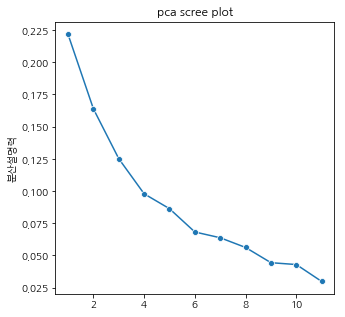

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

xx = d1[n_cols]


#거리기반 방식이므로 먼저 정규화
sc = StandardScaler()
xx = sc.fit_transform(xx)
#pca 적용
pca = PCA()
xx = pca.fit_transform(xx)

rs = pd.DataFrame({
    "고윳값": pca.singular_values_, 
    "분산설명력": pca.explained_variance_ratio_, 
    "누적분산설명력": np.cumsum(pca.explained_variance_ratio_)
})

display(rs)

plt.figure(figsize=(5, 5))
sns.lineplot(data=rs, x=rs.index+1, y="분산설명력", marker='o')
plt.title("pca scree plot")
plt.show()

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = n_cols
vif['vif'] = [variance_inflation_factor(xx, i) for i in range(len(n_cols))]
display(vif[1:])

,name,vif
1,ALB,1.0
2,ALP,1.0
3,ALT,1.0
4,AST,1.0
5,BIL,1.0
6,CHE,1.0
7,CHOL,1.0
8,CREA,1.0
9,GGT,1.0
10,PROT,1.0


pca를 통해 누적분산설명률의 약 80% 이상인 지점을 선택하면 7개의 주성분축으로 새로운 파생변수를 생성할 수 있다.  
이를 통해 vif를 다시 확인하면 1로 다중공선성이 제거된 것을 확인할 수 있음

## 2-1 데이터 불균형이 왜 문제인지 설명하고 불균형 해결방법에 대해 두가지를 설명하라

소수 클래스에 대한 샘플이 적으면, 모델은 다수클래스에 편향된 예측을 내리기 때문에 소수클래스에 대한 예측력이 저하된다.  
(recall 점수 낮음)  

이를 해결하기 위한 방법 2가지     
- 오버샘플링: 소수클래스 샘플을 다수클래스에 맞추어 증강시킴, SMOTE를 상ㅇ하면 소수클래스 샘플과 이웃 간 선형보간으로   
  합성샘플 생성이 가능, SMOTE는 과적합 우려가 적고 일반화 성능이 증가되나, 경계근처 노이즈 증식 위험이 있음  
- 앙상블 기법 사용: 배깅, 부스팅 기반 모델은 불균형 데이터에 비교적 강건한 특성(불순도 기반으로 트리를 분할하므로) 

## 2-2 불균형 데이터 분류모델에 적합한 평가지표 3개 제시하고 그 이유 설명하라

- 정밀도와 재현율: 이 두가지는 일반적으로 trade-off 관계이다. 따라서 예측의 정확도인 정밀도와 실제값을 얼마나 정확하게 예측하는지를  
  동시에 확인하면서 성능을 비교한다. (macro, 두 클래스의 평균지표로 확인)
- F1 SCORE: 정밀도와 재현율이 상충(trade-off) 관계일 때, 두 지표의 균형점을 한 값으로 평가할 수 있음   
  특히 소수 클래스가 놓치는 경우를 모두 반영하므로 불균형 상황에서 비교적 공정한 단일 지표로 유용함
- PR-AUC: PR-AUC(Precision-Recall Area Under Curve)는 정밀도-재현율 곡선(PR Curve) 아래 면적을 의미하며,   
  특히 불균형 데이터에서 모델 성능을 평가할 때 유용

## 2-3 종속 변수를 정상(Category 0)과 비정상(Category 1,2,3)로 변경한 후 위의 2가지 불균형 처리 방법을 사용하고, 3가지 평가지표로 결과를 각각 평가하라.
(학습 규칙)
- 종속 변수를 이진화 후 불균형 처리 방법 진행
- 전처리 후 데이터 행의 index number를 초기화 하라(0부터 시작)
- index number 값이 5로 나눈 나머지가 0이라면 test, 그 외의 경우 train set으로 하여 진행
- 3가지 분류 모델을 사용하라

In [19]:
d1['cat'] = np.where(d1['Category'] == '0=B', 0, 1) 

print(d1['cat'].value_counts())

0    526
1     56
Name: cat, dtype: int64


In [20]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import make_column_transformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score, classification_report

d1 = d1.reset_index(drop=True)

train, test = d1[d1.index % 5 != 0], d1[d1.index % 5 == 0]

train_x, train_y = train.drop(columns=['Category', 'cat']), train['cat']
test_x, test_y = test.drop(columns=['Category', 'cat']), test['cat']


n_cols = train_x.select_dtypes('number').columns
c_cols = train_x.select_dtypes('O').columns

processor = make_column_transformer(
    (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.8))]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

rf = Pipeline([
    ('processor', processor), 
    ('smote', SMOTE(random_state=42)), 
    ('cl', RandomForestClassifier(random_state=42))
])

dt_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['데이터', 'recall', 'precision', 'f1', 'pr_auc'])

rf.fit(train_x, train_y)
for d_name, x, y in dt_list:
    pred = rf.predict(x)
    recall = recall_score(y, pred, average='macro')
    pc = precision_score(y, pred, average='macro')
    pr_auc = average_precision_score(y, pred, average='macro')
    f1 =  f1_score(y, pred, average='macro')
    print(classification_report(y, pred))
    rs.loc[len(rs)] = [d_name, recall, pc, f1, pr_auc]    
display(rs)

Using TensorFlow backend.


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       420
           1       1.00      1.00      1.00        45

    accuracy                           1.00       465
   macro avg       1.00      1.00      1.00       465
weighted avg       1.00      1.00      1.00       465

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       106
           1       0.83      0.91      0.87        11

    accuracy                           0.97       117
   macro avg       0.91      0.95      0.93       117
weighted avg       0.98      0.97      0.97       117



,데이터,recall,precision,f1,pr_auc
0,train,1.000000,1.000000,1.000000,1.000000
1,test,0.945111,0.911905,0.927674,0.766123


smote, 배깅기반 앙상블 모델 적용으로 불균형 데이터 처리 결과, test set 기준 정밀도, 재현율, f1-score는 비교적 높은 예측 성능을   
보여주고 있다. pr_auc는 0.778533로 train set에 비해 다소 낮다. 

recall(0.945111), precision(0.911905, f1(0.927674), pr_auc(0.766123)  

## 3-1 1에서 전처리 완료한 데이터를 바탕으로 종속변수에서 0을 제외한 1,2,3의 데이터만 필터하여 분류모델 학습 및 평가를 진행하라. 
(학습 규칙)
- 전처리 후 데이터 행의 index number를 초기화 하라(0부터 시작)
- index number 값이 5로 나눈 나머지가 0이라면 test, 그 외의 경우 train set으로 하여 진행
- 3개의 분류 모델을 사용하라

In [21]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, classification_report
d1_1 = d1.copy()

d1_1 = d1[d1['Category'] != '0=B']
d1_1['Category'] = d1_1['Category'].str[:1].astype(int).round(0)

print(d1_1['Category'].value_counts())


d1_1 = d1_1.reset_index(drop=True)

train, test = d1_1[d1_1.index % 5 != 0], d1_1[d1_1.index % 5 == 0]

train_x, train_y = train.drop(columns=['Category', 'cat']), train['Category']
test_x, test_y = test.drop(columns=['Category', 'cat']), test['Category']


n_cols = train_x.select_dtypes('number').columns
c_cols = train_x.select_dtypes('O').columns

processor = make_column_transformer(
    (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.8))]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

rf = Pipeline([
    ('processor', processor), 
    ('cl', RandomForestClassifier(random_state=42))
])

lr = Pipeline([
    ('processor', processor), 
    ('cl', LogisticRegression(random_state=42))
])

xgb = Pipeline([
    ('processor', processor), 
    ('cl', XGBClassifier(random_state=42))
])

model_list = [('랜덤포레스트', rf), ('로지스틱 회귀', lr), ('xgbbost', xgb)]
dt_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['모델', '데이터', 'recall', 'precision', 'f1', 'roc_auc'])

for m_name, model in model_list:
    model.fit(train_x, train_y)
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        proba = model.predict_proba(x)
        recall = recall_score(y, pred, average='macro')
        pc = precision_score(y, pred, average='macro')
        f1 =  f1_score(y, pred, average='macro')
        roc_auc = roc_auc_score(y, proba, average='macro', multi_class='ovo')
        print(classification_report(y, pred))
        rs.loc[len(rs)] = [m_name, d_name, recall, pc, f1, roc_auc]
display(rs)

3    24
1    20
2    12
Name: Category, dtype: int64
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00        19

    accuracy                           1.00        44
   macro avg       1.00      1.00      1.00        44
weighted avg       1.00      1.00      1.00        44

              precision    recall  f1-score   support

           1       0.60      0.75      0.67         4
           2       1.00      0.33      0.50         3
           3       0.83      1.00      0.91         5

    accuracy                           0.75        12
   macro avg       0.81      0.69      0.69        12
weighted avg       0.80      0.75      0.73        12

              precision    recall  f1-score   support

           1       0.74      0.88      0.80        16
           2       0.67      0.44      0.53         9
           3       0.9

,모델,데이터,recall,precision,f1,roc_auc
0,랜덤포레스트,train,1.000000,1.000000,1.000000,1.000000
1,랜덤포레스트,test,0.694444,0.811111,0.691919,0.752778
2,로지스틱 회귀,train,0.755604,0.783626,0.760234,0.926291
3,로지스틱 회귀,test,0.694444,0.700000,0.688889,0.802778
4,xgbbost,train,1.000000,1.000000,1.000000,1.000000
5,xgbbost,test,0.694444,0.811111,0.691919,0.836111


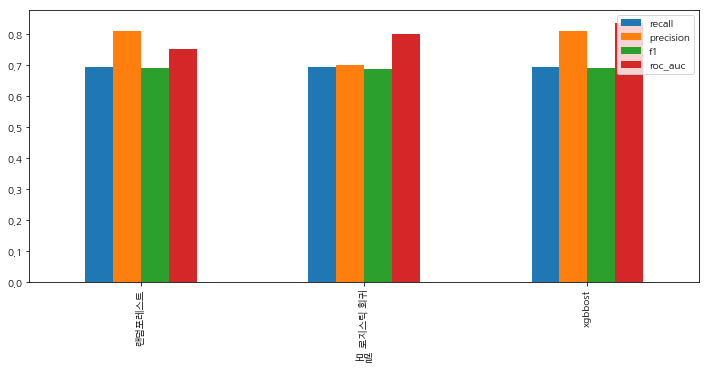

In [22]:
#시각화
tmp = rs[rs['데이터'] == 'test'].drop(columns=['데이터'])
tmp = tmp.set_index('모델')
ax = tmp.plot(kind='bar', figsize=(12, 5))
plt.show()

0레이블을 제외한 결과는 불균형한 데이터가 아니므로 불균형 처리를 하지 않는다. 

세 분류모델을 3가지 평가지표로 비교한 결과, 부스팅 기반 앙상블 모델인 xgbbost 모델의 성능이 가장 뛰어났다.   
(recall, precision, f1 score는 랜덤포레스트와 동일하나, roc_auc score가 0.836111로 더 높음)

## 3-2 학습한 모델 결과와 평가지표를 바탕으로 간염여부에 영향을 미치는 요소들에 대해 논의하라

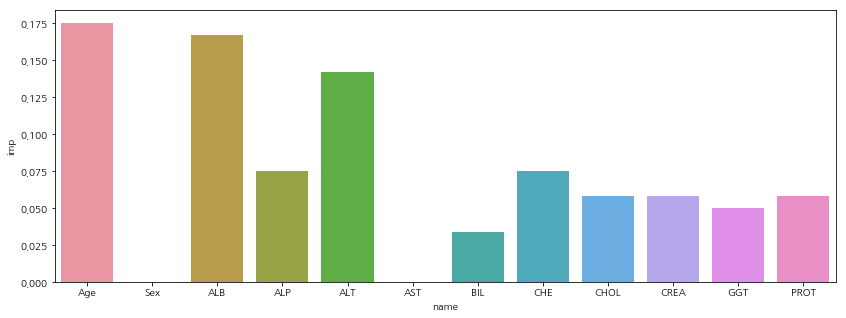

In [23]:
# permutation imp

from sklearn.inspection import permutation_importance

f_imp = permutation_importance(xgb, test_x, test_y, n_repeats=10, random_state=42)
feat = train_x.columns

f_mean = f_imp.importances_mean
f_imp_df = pd.DataFrame({'name': feat, 'imp': f_mean})

plt.figure(figsize=(14, 5))
sns.barplot(data=f_imp_df, x='name', y='imp')

plt.show()
    

permutation imp 는 변수값을 무작위로 섞어 성능 변화를 측정하는 기법이다.  
xgboost classifier 모델을  tset set으로 10번 반복측정하여 성능변화를 확인했을 때  
Age, ALB, ALT 순으로 모델학습에 중요한 영향을 주며, sex, ast는 영향을 주지 않는다는 것을 알 수 있다.  

따라서 중요한 변수만 선택하여 다중공선성 확인 후 다중공선성이 없다면 변수선택만으로도 원데이터의 분포 손실 없이   
중요한 특징을 부각시켜서 학습함으로써 보다 나은 성능을 보여줄 수 있을 것이다. 

## 데이터 설명
- 데이터 출처 : https://www.data.go.kr/data/15048032/fileData.do / 후처리, 통계청 날씨정보
- 데이터 링크 : 
    - ./p2_sb_2021.csv
    - ./p2_sb_2022.csv
    - ./p2_sb_2023.csv
    - ./p2_w_2021.csv
    - ./p2_w_2022.csv
    - ./p2_w_2023.csv
- 데이터 설명 : 
    - 21년~23년의 J시의 2개 지하철호선 지하철의 시간대별 승하차 인원 정보 데이터 (p2_sb_년도.csv)
        - X5~ X22 : 5시부터 22시 승차 또는 하차 인원, (X5 : 05시의 계절 날짜와 대응)
        - 역번호 : 각 정류장의 고유 번호
        - 승하차구분 : 승차 또는 하차
    - 21년~23년의 J시의 특정지역구의 시간대별 게절성 정보 데이터 (p2_w_년도.csv)
        - 시간별 J시의 날씨정보 

In [24]:
m1= pd.read_csv('./p2_sb_2021.csv')
m2= pd.read_csv('./p2_sb_2022.csv')
m3= pd.read_csv('./p2_sb_2023.csv')
weather1 = pd.read_csv('./p2_w_2021.csv')
weather2 = pd.read_csv('./p2_w_2022.csv')
weather3 = pd.read_csv('./p2_w_2023.csv')

In [25]:
m1.shape,m2.shape,m3.shape,weather1.shape,weather2.shape,weather3.shape

((60856, 22), (60914, 22), (61020, 22), (8760, 10), (8760, 10), (8760, 10))

In [26]:
m = pd.concat([m1, m2, m3], axis=0)
w = pd.concat([weather1, weather2, weather3], axis=0)

display(m.head())
display(w.head())

,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,...,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2021-01-01,A,201,승차,22.0,25,61,64,58,53,...,109,149,196,168,178,177,117,138,90,58
1,2021-01-01,A,201,하차,12.0,49,87,142,101,110,...,105,125,114,86,119,63,26,25,62,18
2,2021-01-01,A,202,승차,43.0,53,70,119,94,103,...,331,323,437,447,881,531,335,441,403,137
3,2021-01-01,A,202,하차,21.0,154,238,727,425,356,...,330,342,321,333,331,163,119,110,137,47
4,2021-01-01,A,203,승차,21.0,27,48,81,62,60,...,156,197,197,203,213,190,145,208,135,76


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2021-01-01 00:00,-8.3,NaN,1.8,66,2.2,1016.4,0.0,0,-6.8
1,2021-01-01 01:00,-8.7,NaN,2.4,68,2.2,1016.4,0.0,0,-6.9
2,2021-01-01 02:00,-9.1,NaN,1.6,69,2.1,1016.2,0.0,0,-7.1
3,2021-01-01 03:00,-9.3,NaN,1.1,70,2.1,1016.8,0.0,0,-7.3
4,2021-01-01 04:00,-9.3,NaN,0.3,71,2.2,1016.2,0.0,0,-7.5


In [27]:
print(m.isna().sum())
print(w.isna().sum())

날짜        0
호선        0
역번호       0
승하차구분     0
X5       24
X6        0
X7        0
X8        0
X9        0
X10       0
X11       0
X12       0
X13       0
X14       0
X15       0
X16       0
X17       0
X18       0
X19       0
X20       0
X21       0
X22       0
dtype: int64
일시           0
기온           0
강수량      23305
풍속          39
습도           0
증기압          0
현지기압         0
전운량          2
중하층운량        0
지면온도         7
dtype: int64


## 4-1 아래 조건들을 참고하여 전처리를 시행하고 훈련데이터에 대한 기초통계량을 구하시오
1. 승하차 데이터에서 X5~X22 모든컬럼이 0의 값을 가지는 경우 해당 날짜,호선,역번호 승하차 행은 제외한다. 
2. 승하차 데이터를 날짜,호선,역번호,시간대별(05~22시) 승객수의 총합을 구하여라(승차 + 하차), 결측치는 0명으로 간주한다. 컬럼명은 users로 변경한다.
3. 날짜 데이터의 강수 데이터는 결측치를 0, 그 외 컬럼의 결측치는 직전값으로 대치한다.
4. 날짜데이터와 일자,시간별 승하차인원 데이터를 동일날짜,시간에 대해 합친다.
5. 일자정보를 바탕으로 주말 여부를 나타내는 weekday컬럼을 추가한다. (주말=1,평일=0)
6. 21년,22년 데이터는 훈련데이터, 23년 데이터는 테스트 데이터로 사용한다.

In [28]:
d_cols = m.columns[4:]
# 승하차 데이터에서 X5~X22 모든컬럼이 0의 값을 가지는 경우 해당 날짜,호선,역번호 승하차 행은 제외
m = m[~(m[d_cols] == 0).all(axis=1)]
# 승하차 데이터를 날짜,호선,역번호,시간대별(05~22시) 승객수의 총합을 구하여라(승차 + 하차), 결측치는 0명으로 간주한다. 
# 컬럼명은 users로 변경
m = m.groupby(['날짜', '호선', '역번호'])[d_cols].sum().reset_index()
m = m.fillna(0)
m = m.melt(id_vars=['날짜', '호선', '역번호'], var_name='time', value_name='users')
m['time'] = m['time'].str.replace('X', '').astype('int').round(0)

#날짜 데이터의 강수 데이터는 결측치를 0, 그 외 컬럼의 결측치는 직전값으로 대치
w['강수량'] = w['강수량'].fillna(0)
o_cols = w.columns[3:]
w[o_cols] = w[o_cols].fillna(method='ffill')

#날짜데이터와 일자,시간별 승하차인원 데이터를 동일날짜,시간에 대해 합친다
w['일시'] = pd.to_datetime(w['일시'])
w['날짜'] = w['일시'].dt.strftime('%Y-%m-%d')
w['time'] = w['일시'].dt.hour.astype('int').round(0)

print(m.shape, w.shape)
display(m.head())
display(w.head())

(1636236, 5) (26280, 12)


,날짜,호선,역번호,time,users
0,2021-01-01,A,201,5,34.0
1,2021-01-01,A,202,5,64.0
2,2021-01-01,A,203,5,39.0
3,2021-01-01,A,204,5,23.0
4,2021-01-01,A,205,5,67.0


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도,날짜,time
0,2021-01-01 00:00:00,-8.3,0.0,1.8,66,2.2,1016.4,0.0,0,-6.8,2021-01-01,0
1,2021-01-01 01:00:00,-8.7,0.0,2.4,68,2.2,1016.4,0.0,0,-6.9,2021-01-01,1
2,2021-01-01 02:00:00,-9.1,0.0,1.6,69,2.1,1016.2,0.0,0,-7.1,2021-01-01,2
3,2021-01-01 03:00:00,-9.3,0.0,1.1,70,2.1,1016.8,0.0,0,-7.3,2021-01-01,3
4,2021-01-01 04:00:00,-9.3,0.0,0.3,71,2.2,1016.2,0.0,0,-7.5,2021-01-01,4


In [29]:
w.drop('일시', axis=1, inplace=True)
mt = pd.merge(m, w, on=['날짜', 'time'], how='left', sort=['날짜', 'time'])
mt.head()

,날짜,호선,역번호,time,users,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2021-01-01,A,201,5,34.0,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6
1,2021-01-01,A,202,5,64.0,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6
2,2021-01-01,A,203,5,39.0,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6
3,2021-01-01,A,204,5,23.0,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6
4,2021-01-01,A,205,5,67.0,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6


In [30]:
# 일자정보를 바탕으로 주말 여부를 나타내는 weekday컬럼을 추가한다. (주말=1,평일=0)
#0월요일, 6: 일요일
mt['요일'] = pd.to_datetime(mt['날짜']).dt.weekday
mt['weekday'] = np.where(mt['요일'].between(5, 6), 1, 0)
mt.head()

,날짜,호선,역번호,time,users,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도,요일,weekday
0,2021-01-01,A,201,5,34.0,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,4,0
1,2021-01-01,A,202,5,64.0,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,4,0
2,2021-01-01,A,203,5,39.0,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,4,0
3,2021-01-01,A,204,5,23.0,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,4,0
4,2021-01-01,A,205,5,67.0,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,4,0


In [31]:
mt.drop('요일', axis=1, inplace=True)

In [32]:
mt['weekday'].value_counts()

0    1167120
1     469116
Name: weekday, dtype: int64

In [33]:
train = mt[mt['날짜'].str[:4].isin(['2021', '2022'])]
test =  mt[mt['날짜'].str[:4].isin(['2023'])]

train.shape, test.shape

((1090620, 15), (545616, 15))

In [34]:
mt.columns

Index(['날짜', '호선', '역번호', 'time', 'users', '기온', '강수량', '풍속', '습도', '증기압',
       '현지기압', '전운량', '중하층운량', '지면온도', 'weekday'],
      dtype='object')

## 4-2 전체 년도 데이터에 대해 users와 날씨 정보에 대해 상관관계를 분석하고 주말여부에 따른 users 변수의 차이가 존재하는지 통계적으로 확인하라.

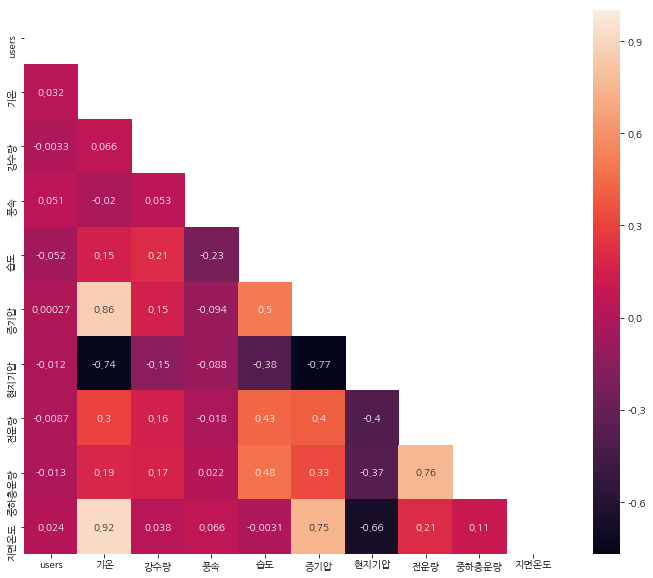

In [35]:
plt.figure(figsize=(12, 10))
w_cols = ['users', '기온', '강수량', '풍속', '습도', '증기압', '현지기압', '전운량', '중하층운량', '지면온도']
corr = mt[w_cols].corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

users와 각 날씨 변수들과는 유의미한 선형 상관관계는 관찰되지 않는다.  
다만, 각 날씨 변수들간에는 강한 음, 양의 상관관계가 관찰된다.  
기온-지면온도는 0.92로 강한 양의 상관관계, 기온-현지기압은 -0.74로 음의 상관관계를 보인다.  
(날씨변수는 서로 연관이 있으므로)

이는 승객수와 날씨변인들 간 다중공선성이 없음을 뜻한다. 

In [36]:
# 주말여부에 따른 user 변수들 간 차이가 존재하는지 여부는 두 그룹 간 평균의 차이가 존재하는가? 로 정규성을 만족한다면  
# 독립변수 ttest 를 통해 확인

from scipy.stats import shapiro, levene

gr = [(name, g['users']) for name, g in mt.groupby(['weekday'])]

for name, g in gr:
    stat, p = shapiro(g)
    print(f"{name} 그룹 정규성 검정결과: 통계량 {stat:.3f} / pvalue: {p:.3f}")

# 정규성 만족 안하므로 맨휘트니 u 검정 실시
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(gr[0][1], gr[1][1])
print(f"맨휘트니 u 검정 결과 통계량 {stat:.3f} / pvalue: {p:.3f}", "독립" if p >= 0.05 else "연관")

0 그룹 정규성 검정결과: 통계량 0.757 / pvalue: 0.000
1 그룹 정규성 검정결과: 통계량 0.735 / pvalue: 0.000
맨휘트니 u 검정 결과 통계량 347858575963.500 / pvalue: 0.000 연관


비모수검정인 맨휘트니 u 검정 결과, 주말여부에 따라 승객수의 차이가 유의미하게 있다.  
이는 주말여부 변수를 사용하여 users를 예측할 수 있음을 뜻한다.

## 4-3 users를 예측하는 2가지 회귀모델을 학습하고 모델에 대해 평가하라 (선형회귀 모델은 1개 필수 포함)

- 선형회귀 모델: 기본적인 선형모델, 종속변수 예측값을 y로 두고 설명변수와 가중치가 되는 계수를 학습을 통해 정해서 선형식으로
  만든 다음 오차를 최소화하는 방식으로 하이퍼파라미터를 최적화 후 예측
- 랜덤포레스트 회귀: 배깅 기반의 트리 앙상블 모델, 이상치에 강건하며, 사용법이 쉬우나, 대규모 데이터 학습속도 느림

In [37]:
train[['역번호', 'time']]= train[['역번호', 'time']].astype('O')
test[['역번호', 'time']]= test[['역번호', 'time']].astype('O')

In [38]:
# 데이터 수가 너무 많아서 train 3만개, test 만개로 예측
train = train.sample(30000)
test = test.sample(10000)

train_x, train_y  = train.drop(['날짜', 'users'], axis=1), train['users']
test_x, test_y  = test.drop(['날짜', 'users'], axis=1), test['users']

n_cols = train_x.select_dtypes('number').columns
c_cols = train_x.select_dtypes('O').columns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

processor = make_column_transformer(
    (Pipeline([('scaler', StandardScaler())]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

lin = Pipeline([
    ('processor', processor), 
    ('rg', LinearRegression())
])

rf = Pipeline([
    ('processor', processor), 
    ('rg', RandomForestRegressor(random_state=42))
])


model_list = [('선형회귀', lin), ('랜덤포레스트 회귀', rf)]
dt_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['모델명', '데이터', 'r2_score', 'rmse'])

for m_name, model in model_list:
    model.fit(train_x, train_y)
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        r2 = r2_score(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        rs.loc[len(rs)] = [m_name, d_name, r2, rmse]
        
display(rs)

,모델명,데이터,r2_score,rmse
0,선형회귀,train,0.658922,1357.385724
1,선형회귀,test,0.629051,1610.974083
2,랜덤포레스트 회귀,train,0.984640,288.054403
3,랜덤포레스트 회귀,test,0.868791,958.105410


기본적인 선형모델과 앙상블 모델인 랜덤포레스트 회귀 모델을 학습한 결과이다.  
랜덤포레스트 회귀의 경우 과적합이 관찰되지만, 기본적인 선형회귀에 비해서 성능이 뛰어나므로 랜덤포레스트 회귀모델을 채택한다.  

test set 기준으로 평가할 때, 랜덤포레스트 모델은 전체 데이터 분산의 약 88.7%(선형회귀는 64.6%)를 설명하며,   
rmse도 858.769475로 전체 데이터 범위(max-min: 228340)의 약 3.76%의 표준오차로 적은 오차를 보인다.  
(선형회귀는 6.65%)  

두 모델 모두 활용 가능한 수준의 성능을 보여주었는데, 이는 학습에 사용된 feature의 특징패턴이 회귀예측을 위해 적절함을 알 수 있다. 

# 통계 (40점)

## 데이터 설명
- 데이터 출처 : 자체 제작
- 데이터 링크 : ./s1.csv
- 데이터 설명 : A,B 두 공장의 특정 일자의 수율(%)데이터. 단, 불량률은 (100 - 수율)로 정의한다.
    

In [39]:
d5 = pd.read_csv('./s1.csv')
d5.head()

,year,month,day,A,B
0,2023,Sep,7,56.9,42.3
1,2023,Feb,20,100.0,89.0
2,2023,Jun,15,19.3,59.0
3,2023,Apr,11,98.0,84.8
4,2023,Jul,8,89.5,63.8


## 5-1 공장별 결측치, 기초통계량 등을 확인하라

결측값 확인:
year     0
month    0
day      0
A        5
B        5
dtype: int64
결측값 삭제 전: 50개
결측값 삭제 후: 40개


,count,mean,std,min,25%,50%,75%,max
A,40.0,75.7175,21.104962,19.3,60.975,79.05,94.475,100.0
B,40.0,70.4425,14.824700,41.6,58.450,71.75,81.800,100.0


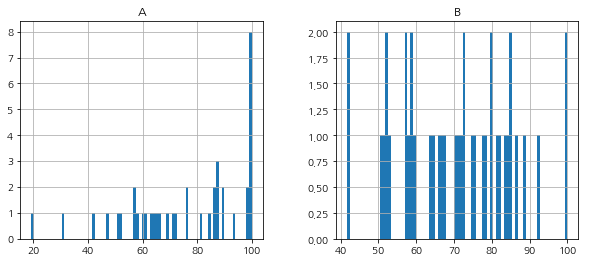

,count,unique,top,freq
year,40,1,2023,40
month,40,11,Feb,7
day,40,21,21,4


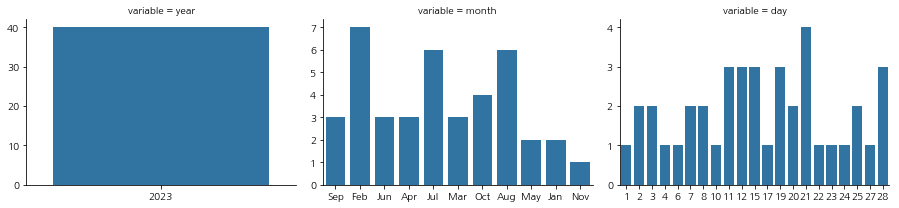

In [40]:
#결측치 확인
print("결측값 확인:")
print(d5.isna().sum())
print(f"결측값 삭제 전: {len(d5)}개")
d5 = d5.dropna()
print(f"결측값 삭제 후: {len(d5)}개")

c_cols = ['year', 'month', 'day']
d5[c_cols] = d5[c_cols].astype('O')

#기초통계량 확인
display(d5.describe().T)
d5.hist(figsize=(10, 4), bins=80, layout=(1, 2))
plt.show()
display(d5[c_cols].describe().T)
mt = d5[c_cols].melt()
g = sns.FacetGrid(mt, col='variable', col_wrap=3, height=3, aspect=1.4, sharex=False, sharey=False)
g.map_dataframe(sns.countplot, x='value')
plt.show()

a, b컬럼에서 각각 5개씩의 결측값이 확인되었다. 총 10개로 이는 전체 데이터의 20% 수준이지만, 관찰된 데이터이므로  
보간을 한다면 데이터의 왜곡을 발생시킬 수 있으므로(이는 통계 문제에 특히 민감) 삭제한다.   

통계량을 보면 A공장의 평균이 B공장의 평균보다 높으며, A공장의 중위값이 평균보다 크므로 좌측 긴꼬리 분포(음의 왜도)이다.   
2, 7, 8월 데이터가 많으며, 5, 1, 11월 데이터가 비교적으로 적다. 
21일 데이터가 가장 많다. 


## 5-2 A,B 공장의 불량률 차이가 존재하는지 확인하려 한다. 귀무,대립 가설을 설정하고 설명하라

두 그룹의 불량률 대푯값(평균) 차이가 존재하는지 확인한기 위함이다.  
정규성을 만족한다면 모수검정인 독립검정 ttest, 만족하지 않는다면 맨휘트니 u 검정을 실시한다. 

- 귀무가설: 두 공장의 불량률 차이가 없다. 
- 대립가설: 두 공장의 불량률 차이가 존재한다. 

## 5-3 A,B의 차이가 있는지 통계검정 하고 설명하라

In [41]:
from scipy.stats import shapiro, levene

d5['Ae'] = 100 - d5['A']
d5['Be'] = 100 - d5['B']

gr = [('A공장', d5['Ae']), ('B공장', d5['Be'])]

for name, g in gr:
    stat, p = shapiro(g)
    print(f"{name} 정규성 검정 통계량 : {stat:.3f} / pvalue: {p:.3f}", "정규성 만족" if p >= 0.05 else "불만족")

A공장 정규성 검정 통계량 : 0.921 / pvalue: 0.008 불만족
B공장 정규성 검정 통계량 : 0.978 / pvalue: 0.615 정규성 만족


In [42]:
# B 공장의 정규성을 만족하지 못하므로 맨위트니 u 검정을 통해 두 공장의 불량률 차이 검정

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(gr[0][1], gr[1][1])
print(f"맨휘트니 u 검정결과, 검정통계량: {stat:.3f} / pvalue: {p:.3f}", "차이있음" if p < 0.05 else "없음")

맨휘트니 u 검정결과, 검정통계량: 630.500 / pvalue: 0.104 없음


맨휘트니 u 검정결과, 유의수준 5% 하에서 p-value가 0.104로 0.05보다 크므로 귀무가설을 기각할 수 없음  
따라서 두 공장의 불량률 차이가 없다. 

## 데이터 설명
- 데이터 출처 : https://www.data.go.kr/data/15123586/fileData.do 후처리
- 데이터 링크 : ./s2.csv
- 데이터 설명 : 일자별 지하철 노션별 지연 데이터

In [43]:
d6 = pd.read_csv('./s2.csv')
d6.head()

,지연ID,지연일자,노선,최대지연시간
0,ID_0,2023-09-01,1호선,15분
1,ID_1,2023-09-01,1호선,15분
2,ID_2,2023-09-01,4호선,10분
3,ID_3,2023-09-01,4호선,10분
4,ID_4,2023-09-04,4호선,10분


## 6-1 노선에 상관없이 일별 최대 지연시간이 5~15분으로 발생하는 경우는 하나의 사건으로 보자. 해당 사건이 일자별 발생하는 빈도가 푸아송분포를 따르는지 확인하는 방법 2가지를 기술하고 결과를 보여라

1. 카이제곱 적합성 검정: 관측된 범주형 자료의 빈도분포가 사전에 정해진 이론적 분포와 일치하는지를 검정하는 통계기법(기대도수 5이상)
  - 가설설정: H0: 관측빈도분포와 포아송 기대분포 간 차이가 없다. / H1: H0: 관측빈도분포와 포아송 기대분포 간 차이가 있다
    (비모수 기법으로 분포가정 불필요, 범주간 비교없이 이론분포와의 적합성만 평가, 샘플크기가 충분할 때 신뢰성 높음)
2. k-s 검정: 두 분포간 차이를 누적분포함수 차이를 통해 검정하는 비모수 검정기법
   (분포가정 불필요, 전체 분포차이 포괄적 검출, 구현 간편)
   - 가설검정:  H0: 관측빈도분포와 포아송 기대분포 간 cdf 차이가 없다. / H1: H0: 관측빈도분포와 포아송 기대분포 간 cdf 차이가 있다

In [44]:
d6['최대지연시간'].value_counts()

10분       414
5분        179
15분       153
20분        58
25분        16
30분 이상     13
Name: 최대지연시간, dtype: int64

In [45]:
rd = d6[d6['최대지연시간'].isin(['5분', '10분', '15분'])]

rd = rd.groupby(['지연일자'])['최대지연시간'].count().reset_index().set_index('지연일자')
rd.head()

,최대지연시간
지연일자,
2023-09-01,4
2023-09-04,2
2023-09-05,3
2023-09-06,4
2023-09-08,4


In [46]:
rd.value_counts().sort_index()

최대지연시간
1          20
2         113
3          26
4          76
5           6
6          11
7           2
8           1
dtype: int64

In [47]:
from scipy.stats import poisson, chisquare, kstest

#1. 카이제곱 적합도검정
lamb = rd.mean() #평균계산
obs_freq = rd.value_counts().sort_index() #사건수별 빈도
expected_freq = [len(rd) * poisson.pmf(k, lamb) for k in obs_freq.index] # 각 사건(수)별 기대빈도
expected_freq = np.array(expected_freq)*obs_freq.sum() / sum(expected_freq) # 기대 도수를 관측 총합에 맞춰 정규화
cstat, p1 = chisquare(obs_freq.values, expected_freq.reshape(-1)) #사건수별 빈도, 각 사건(수)별 기대빈도

print(f"카이제곱 적합도 검정 통계량: {cstat}")
print(f"카이제곱 적합도 검정 p-value: {p1:.3f} 으로 귀무가설", "기각(포아송x)" if p1<0.05 else "기각x(포아송)")

카이제곱 적합도 검정 통계량: 114.09447581705476
카이제곱 적합도 검정 p-value: 0.000 으로 귀무가설 기각(포아송x)


In [48]:
from scipy.stats import poisson, chi2, chisquare, kstest

#카이제곱 적합도 검정
p_mean = rd.mean()

#사건수별 빈도(각 지연시간별 발생 횟수)
o_freq = rd.value_counts().sort_values()

#각 사건수별 포아송 기대빈도: 전체도수*포아송 확률분포(사건[1~8], 평균)
e_freq = [len(rd)*poisson.pmf(k, p_mean) for k in o_freq.index]
#정규화
e_freq = np.array(e_freq)*o_freq.sum() / sum(e_freq)
# 관측분포, 포아송 분포 비교
stat, p  = chisquare(o_freq.values, e_freq.reshape(-1))

print(f"카이제곱 적합도 검정 통계량 : {stat:.3f}")
print(f"카이제곱 적합도 검정 pvalue: {p:.3f}", "분포 같음" if p >= 0.05 else "분포 다름")

카이제곱 적합도 검정 통계량 : 114.094
카이제곱 적합도 검정 pvalue: 0.000 분포 다름


In [49]:
# kolmogorov-smirov 검정
stat, p = kstest(rd, 'poisson', args=(p_mean, ))

print(f"ks 검정 통계량 : {stat:.3f}")
print(f"ks 검정 pvalue: {p:.3f}", "분포 같음" if p >= 0.05 else "분포 다름")

ks 검정 통계량 : 0.997
ks 검정 pvalue: 0.000 분포 다름


두 검정 결과, 유의수준 5% 하에서 pvalue가 0.05보다 작으므로 귀무가설을 기각한다.  
따라서 일별 최대 지연시간이 5~15분으로 발생하는 경우의 빈도는 포아송 분포를 따르지 않는다. 

## 6-2 10분이하, 10분초과 -20분 이하, 20분초과  3가지로 지연시간을 지연정도로 분류하라. 호선별 지연정도를 교차표로 구하여라

In [50]:
cond1 = d6['최대지연시간'].isin(['5분', '10분'])
cond2 = d6['최대지연시간'].isin(['15분', '20분'])

d6['지연정도'] = np.where(cond1, '10분 이하', np.where(cond2, '10분초과-20분이하', '20분초과'))

display(d6.head())
cr = pd.crosstab(d6['노선'], d6['지연정도'])
display(cr)

,지연ID,지연일자,노선,최대지연시간,지연정도
0,ID_0,2023-09-01,1호선,15분,10분초과-20분이하
1,ID_1,2023-09-01,1호선,15분,10분초과-20분이하
2,ID_2,2023-09-01,4호선,10분,10분 이하
3,ID_3,2023-09-01,4호선,10분,10분 이하
4,ID_4,2023-09-04,4호선,10분,10분 이하


지연정도,10분 이하,10분초과-20분이하,20분초과
노선,,,
1호선,269,67,16
4호선,324,144,13


## 6-3 지하철 호선별로 지연정도가 차이가 있는지 확인하려한다. 귀무가설과 대립가설을 설정한 후 통계 검정을 실시하라

지하철 호선, 지연정도 모두 명목형 변수이며, 두 명목형 변수의 차이 여부를 검정하는 방법을 수행해야 한다.   
지하철 호선 별로 지연정도 차이가 있는지 검정하기 위해 비모수 검정방법인 카이제곱 독립성 검정을 수행한다.
(유의수준 5% 하)

- 귀무가설: 호선별로 지연정도 차이가 없다.(호선과 자연정도는 독립적) 
- 대립가설: 호선별로 지연정도 차이가 있다.(호선과 지연정도는 연관)

In [51]:
from scipy.stats import chi2_contingency

stat, p, ddof, expected = chi2_contingency(cr)

print(f"카이제곱 독립성 검정 통계량 : {stat:.3f}")
print(f"p-value: {p:.3f}, 귀무가설", "기각" if p < 0.05 else "채택")

카이제곱 독립성 검정 통계량 : 13.866
p-value: 0.001, 귀무가설 기각


카이제곱 독립성 검정 결과, p-value 0.001로 귀무가설을 기각한다.  
따라서 호선별로 지연정도 차이가 있다.는 대립가설은 통계적으로 유의하다.

## 데이터 설명
- 데이터 출처 : 자체제작
- 데이터 링크 : ./s3.csv
- 데이터 설명 : 시계열 정보를 가지는 250행의 데이터

In [52]:
d7 = pd.read_csv('./s3.csv',names=['value']) 
d7.head()

,value
0,0.496714
1,0.308778
2,0.692133
3,2.070861
4,1.326845


## 7-1 ar ma arma에 대해 설명하고, ACF, PACF는 패턴을 통해 설명하라.

- AR모델: 자기회귀 모델로 현재 시점의 값이 자기자신의 값들의 선형결합으로 표현되는 모델이다. 정상성을 가정한다.    
  차수는 p를 사용하며, PACF(중간시차들의 영향을 제거한 후 특정 lag에서 순수한 상관관계 특성함수)에서 신뢰구간에 들어가기 직전의    
  peak를 p로 선택한다. ACF 패턴은 점차적으로 감소하는 형태, 또는 사인파형을 보인다. 
- MA 모델: 이동평균 모델로 현재시점의 값이 과거의 오차항들의 선형결합으로 표현되는 모델이다. 정상성을 가정한다.    
  차수는 q를 사용하며, ACF(시계열과 자신의 지연된 값들 간의 상관계수를 lag별로 나타낸 함수)에서 신뢰구간에 들어가기 직전의  
  peak를 선택한다. PACF에서는 점차적으로 감소하거나 사인 파형의 형태를 보인다.  
- ARMA 모델: AR과 MA를 결합한 모델로 정상성을 가정한다.   
  ACF와 PACF에서 모두 점차적으로 감소하거나, 사인 파형의 형태를 보인다.

## 7-2 Acf pacf를 그리고 해석하라, 해당 Plot data를 기반으로 ARMA(p,q)모형 제시하라

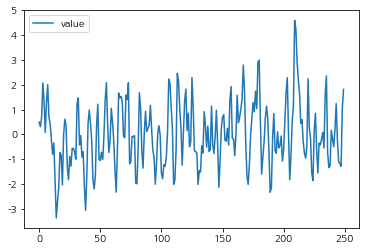

In [53]:
sns.lineplot(data=d7)
plt.show()

adfuller 통계량 -5.615004257611433
pvalue: 0.000 정상성 만족


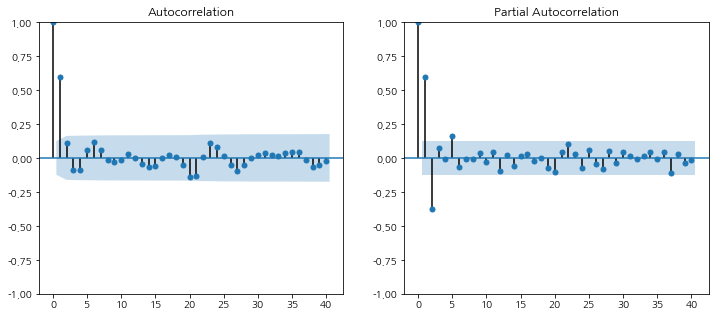

In [54]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#정상성 여부 확인
rs = adfuller(d7)

print("adfuller 통계량", rs[0])
print(f"pvalue: {rs[1]:.3f}", '정상성 만족' if rs[1] < 0.05 else "불만족")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(d7, lags=40, ax=ax[0])
plot_pacf(d7, lags=40, ax=ax[1])
plt.show()

일단 adfuller 검정결과, 귀무가설을 기각(단위근이 없다.)하므로 정상성은 만족한다.  
ACF와 PACF 그래프에서 점차적으로 감소하거나 사인파형을 그리지 않으므로 ARMA 모델을 선택한다.  

차수는 다음과 같이 추천한다.  
- p : 2 / PACF에서 lag2에서 peak후 이후 비교적 신뢰구간 내 위치
- q: 1 / acf에서 lag1 에서 peak후 모두 신뢰구간 내 위치 

In [55]:
d7

,value
0,0.496714
1,0.308778
2,0.692133
3,2.070861
4,1.326845
...,...
245,-1.085300
246,-1.179062
247,-1.286190
248,1.033554


In [56]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(d7['value'], order=[2, 0, 1]).fit()

print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  250
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -345.443
Date:                Sat, 27 Sep 2025   AIC                            700.887
Time:                        16:26:35   BIC                            718.494
Sample:                             0   HQIC                           707.973
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0051      0.122     -0.042      0.966      -0.244       0.233
ar.L1          0.6199      0.172      3.613      0.000       0.284       0.956
ar.L2         -0.2538      0.120     -2.115      0.0

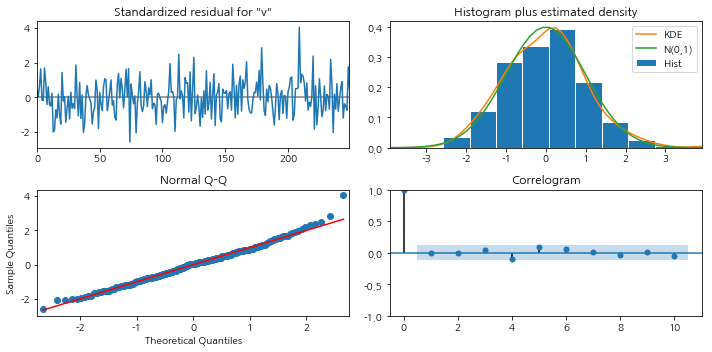

In [57]:
model.plot_diagnostics(figsize=(10, 5))
plt.tight_layout()
plt.show()

plot 상 정규성, 등분산성, 선형성, 독립성을 만족하는 것으로 판단됨  
(정규성은 검정결과 만족하지 않음)

In [58]:
print('끝, ##쪽')

끝, ##쪽
